In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import os
os.makedirs('../results/eda_visualizations', exist_ok=True)

In [4]:
import os
os.chdir(os.path.dirname(os.path.abspath("__file__"))) if False else None

In [5]:
import os
print(os.getcwd())
print(os.listdir())

c:\Users\ADMIN\Downloads\AIML_PROJECT_OFFICIAL_Y2S1\MLBG11.02_07_AIML\notebooks
['df.md', 'IT25100059_Dimensionality_Reduction_PCA.ipynb', 'IT25100059_Model_Neural_Network.ipynb', 'IT25100059__Dimensionality_Reduction_PCA.ipynb', 'IT25100504_Missing_Data_Handling.ipynb', 'IT25100504_Model_Logistic_Regression.ipynb', 'IT25101432_Outlier_Removal.ipynb', 'IT25101432__Model_Decision_Tree.ipynb', 'IT25102218_Feature_Selection.ipynb', 'IT25102218_Model_SVM.ipynb', 'IT25102603_Model_Random_Forest.ipynb', 'IT25102603_Normalization_Scaling.ipynb', 'IT25103179_Encoding_Categorical_Variables.ipynb', 'IT25103179__Model_KNN.ipynb', 'Models', 'results']


In [6]:
# Read the ARFF file manually (it was saved as df.md but the content is ARFF format)
with open('../data/raw/Rice_Cammeo_Osmancik.arff', 'r') as f:
    lines = f.readlines()

# Column names, in the order they appear in @ATTRIBUTE lines
columns = ['Area', 'Perimeter', 'Major_Axis_Length', 'Minor_Axis_Length',
           'Eccentricity', 'Convex_Area', 'Extent', 'Class']

# Find where the actual data starts (after the @DATA line)
data_start = next(i for i, l in enumerate(lines) if l.strip().upper() == '@DATA') + 1
data_lines = [l.strip() for l in lines[data_start:] if l.strip()]

# Parse into a DataFrame
rows = [l.split(',') for l in data_lines]
df = pd.DataFrame(rows, columns=columns)

# Convert numeric columns from text to actual numbers
num_cols = columns[:-1]
df[num_cols] = df[num_cols].astype(float)

# Save a clean CSV for every other notebook to reuse
df.to_csv('../data/raw/rice.csv', index=False)

print(df.shape)
df.head()

(3810, 8)


,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
0,15231.0,525.578979,229.749878,85.093788,0.928882,15617.0,0.572896,Cammeo
1,14656.0,494.311005,206.020065,91.730972,0.895405,15072.0,0.615436,Cammeo
2,14634.0,501.122009,214.106781,87.768288,0.912118,14954.0,0.693259,Cammeo
3,13176.0,458.342987,193.337387,87.448395,0.891861,13368.0,0.640669,Cammeo
4,14688.0,507.166992,211.743378,89.312454,0.906691,15262.0,0.646024,Cammeo


In [3]:
# Read the ARFF file manually
with open(r'C:\Users\ADMIN\Downloads\AIML_PROJECT_OFFICIAL_Y2S1\MLBG11.02_07_AIML\data\raw\Rice_Cammeo_Osmancik.arff', 'r') as f:
    lines = f.readlines()

In [4]:
print(df)

         Area   Perimeter  Major_Axis_Length  Minor_Axis_Length  Eccentricity  \
0     15231.0  525.578979         229.749878          85.093788      0.928882   
1     14656.0  494.311005         206.020065          91.730972      0.895405   
2     14634.0  501.122009         214.106781          87.768288      0.912118   
3     13176.0  458.342987         193.337387          87.448395      0.891861   
4     14688.0  507.166992         211.743378          89.312454      0.906691   
...       ...         ...                ...                ...           ...   
3805  11441.0  415.858002         170.486771          85.756592      0.864280   
3806  11625.0  421.390015         167.714798          89.462570      0.845850   
3807  12437.0  442.498993         183.572922          86.801979      0.881144   
3808   9882.0  392.296997         161.193985          78.210480      0.874406   
3809  11434.0  404.709991         161.079269          90.868195      0.825692   

      Convex_Area    Extent

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA

num_cols = df.columns[:-1]
X = df[num_cols]
y = df['Class']

# PCA requires standardized input since it is variance-based
X_scaled = StandardScaler().fit_transform(X)


In [6]:
#Fit_PCA_and_inspect_explained_variance
pca_full = PCA()
pca_full.fit(X_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = explained.cumsum()

pd.DataFrame({
    'Component': [f'PC{i+1}' for i in range(len(explained))],
    'Explained Variance %': (explained*100).round(2),
    'Cumulative %': (cumulative*100).round(2)
})


,Component,Explained Variance %,Cumulative %
0,PC1,65.41,65.41
1,PC2,21.43,86.84
2,PC3,12.87,99.71
3,PC4,0.17,99.88
4,PC5,0.09,99.96
5,PC6,0.03,99.99
6,PC7,0.01,100.00


FileNotFoundError: [Errno 2] No such file or directory: '../results/eda_visualizations/member6_pca_scree_plot.png'

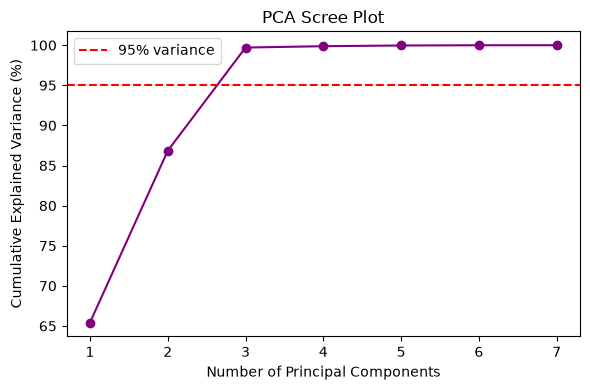

In [7]:
#EDA_Visualization-Scree_plot_(explained_variance_per_component)
plt.figure(figsize=(6,4))
plt.plot(range(1, len(explained)+1), cumulative*100, marker='o', color='purple')
plt.axhline(95, color='red', linestyle='--', label='95% variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('PCA Scree Plot')
plt.legend()
plt.tight_layout()
plt.savefig('../results/eda_visualizations/member6_pca_scree_plot.png', dpi=150)
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '../results/eda_visualizations/member6_pca_scatter.png'

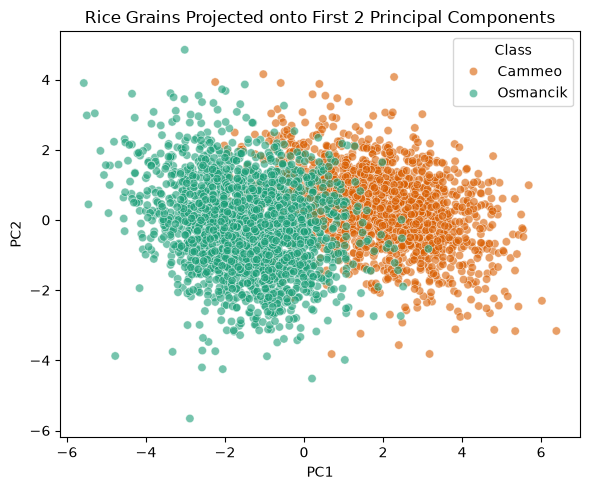

In [8]:
#Reduce_to_2_components_and_visualize_class_separability
pca_2 = PCA(n_components=2)
X_pca = pca_2.fit_transform(X_scaled)

df_pca = pd.DataFrame(X_pca, columns=['PC1','PC2'])
df_pca['Class'] = y.values

plt.figure(figsize=(6,5))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Class', alpha=0.6, palette=['#d95f02','#1b9e77'])
plt.title('Rice Grains Projected onto First 2 Principal Components')
plt.tight_layout()
plt.savefig('../results/eda_visualizations/member6_pca_scatter.png', dpi=150)
plt.show()

print(f"PC1 + PC2 explain {pca_2.explained_variance_ratio_.sum()*100:.2f}% of total variance")
